In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [76]:
df = pd.read_csv("vehicles.csv", engine="python", on_bad_lines='skip')

In [77]:
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4706 entries, 0 to 4705
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            4706 non-null   int64  
 1   url           4706 non-null   object 
 2   region        4706 non-null   object 
 3   region_url    4706 non-null   object 
 4   price         4706 non-null   int64  
 5   year          4625 non-null   float64
 6   manufacturer  4406 non-null   object 
 7   model         4645 non-null   object 
 8   condition     2701 non-null   object 
 9   cylinders     2991 non-null   object 
 10  fuel          4611 non-null   object 
 11  odometer      4667 non-null   float64
 12  title_status  4544 non-null   object 
 13  transmission  4676 non-null   object 
 14  VIN           2910 non-null   object 
 15  drive         3088 non-null   object 
 16  size          1309 non-null   object 
 17  type          3492 non-null   object 
 18  paint_color   3698 non-null 

In [79]:
df.describe()

,id,price,year,odometer,county,lat,long
count,4.706000e+03,4.706000e+03,4625.000000,4.667000e+03,0.0,4640.000000,4640.000000
mean,7.309412e+09,2.506757e+05,2011.737514,1.373148e+05,NaN,33.511951,-86.289414
std,8.254262e+06,1.447023e+07,9.540223,6.478206e+05,NaN,2.639321,2.568570
min,7.208550e+09,0.000000e+00,1903.000000,0.000000e+00,NaN,-81.838232,-122.693000
25%,7.306193e+09,7.500000e+03,2009.000000,3.035900e+04,NaN,32.466515,-86.980000
50%,7.310403e+09,1.850000e+04,2014.000000,7.910100e+04,NaN,33.521000,-86.737847
75%,7.313785e+09,2.959000e+04,2017.000000,1.431185e+05,NaN,34.653880,-86.053098
max,7.316886e+09,9.876543e+08,2021.000000,9.999999e+06,NaN,44.120200,-73.572300


In [80]:
df.isnull().sum()

,0
id,0
url,0
region,0
region_url,0
price,0
year,81
manufacturer,300
model,61
condition,2005
cylinders,1715


In [81]:
drop_cols = ['id', 'url', 'region_url', 'image_url', 'county', 'VIN']
df.drop(columns=drop_cols, inplace=True)

In [82]:
df.rename(columns={
    'manufacturer': 'brand',
    'year': 'year_of_manufacture',
    'odometer': 'km',
    'type': 'car_type',
    'paint_color': 'color',
    'cylinders': 'engine_cylinders',
    'transmission': 'gearbox',
    'drive': 'drive_type',
    'title_status': 'title_condition',
    'region': 'city'
}, inplace=True)

In [83]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4706 entries, 0 to 4705
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   city                 4706 non-null   object 
 1   price                4706 non-null   int64  
 2   year_of_manufacture  4625 non-null   float64
 3   brand                4406 non-null   object 
 4   model                4645 non-null   object 
 5   condition            2701 non-null   object 
 6   engine_cylinders     2991 non-null   object 
 7   fuel                 4611 non-null   object 
 8   km                   4667 non-null   float64
 9   title_condition      4544 non-null   object 
 10  gearbox              4676 non-null   object 
 11  drive_type           3088 non-null   object 
 12  size                 1309 non-null   object 
 13  car_type             3492 non-null   object 
 14  color                3698 non-null   object 
 15  description          4679 non-null   o

In [84]:
df['lat'].unique()


array([       nan,  32.59    ,  32.592   ,  32.6013  ,  32.6454  ,
        32.5475  ,  32.628739,  32.6304  ,  32.8224  ,  32.629409,
        32.8113  ,  32.614209,  32.6024  ,  32.8337  ,  31.425091,
        32.4169  ,  32.6099  ,  32.562007,  33.384664,  33.2663  ,
        33.6035  ,  34.657607,  33.455361,  33.52    ,  33.614088,
        33.415861,  33.649773,  33.669601,  33.5884  ,  33.7677  ,
        32.9229  ,  33.168322,  33.13435 ,  33.3224  ,  33.5179  ,
        33.521   ,  36.1379  ,  34.0013  ,  33.9135  ,  33.5979  ,
        33.6053  ,  33.3538  ,  28.0091  ,  33.5554  ,  33.3813  ,
        33.971956,  33.1248  ,  33.5066  ,  33.5363  ,  33.5062  ,
        33.4653  ,  28.3648  ,  36.0127  ,  34.188155,  33.158449,
        33.546749,  33.47621 ,  33.1717  ,  33.4679  ,  33.2932  ,
        33.209789,  35.7173  ,  33.339133,  33.6328  ,  34.6205  ,
        33.515444,  33.6339  ,  34.1761  ,  33.925578,  33.120694,
        33.3967  ,  33.493   ,  32.8355  ,  34.2056  ,  33.910

In [85]:
df['long'].unique()

array([        nan,  -85.48    ,  -85.5189  ,  -85.443974,  -85.3783  ,
        -85.4682  ,  -85.46182 ,  -85.4016  ,  -85.7704  ,  -85.484447,
        -85.1749  ,  -85.326357,  -85.4873  ,  -85.1197  ,  -85.617723,
        -85.7094  ,  -85.4808  ,  -85.66967 ,  -86.737847,  -86.902   ,
        -86.4668  ,  -87.782814,  -86.962474,  -86.79    ,  -85.796729,
        -86.988407,  -86.610105,  -86.817617,  -86.9597  ,  -85.0133  ,
        -86.545   ,  -87.491902,  -86.619515,  -86.9657  ,  -86.8372  ,
        -86.8066  ,  -86.741   ,  -86.9381  ,  -84.6859  ,  -86.3432  ,
        -84.4813  ,  -86.8254  ,  -82.5034  ,  -86.887   ,  -86.7046  ,
        -86.053098,  -86.8622  ,  -86.7428  ,  -87.051   ,  -86.8003  ,
        -86.8082  ,  -82.6757  ,  -86.56    ,  -86.851389,  -86.942271,
        -86.539801,  -86.715994,  -86.2713  ,  -84.4806  ,  -86.768   ,
        -86.783493,  -86.9048  ,  -86.920052,  -86.6493  ,  -86.551   ,
        -86.793624,  -86.5981  ,  -86.8298  ,  -84.836041,  -86.

In [86]:
df['fuel'].unique()

array([nan, 'gas', 'other', 'diesel', 'hybrid', 'electric'], dtype=object)

In [87]:
df['gearbox'].unique()

array([nan, 'other', 'automatic', 'manual'], dtype=object)

In [88]:
df['drive_type'].unique()

array([nan, 'rwd', '4wd', 'fwd'], dtype=object)

In [89]:
df['condition'].unique()

array([nan, 'good', 'excellent', 'fair', 'like new', 'new', 'salvage'],
      dtype=object)

In [90]:
df.drop(columns=['size'], inplace=True)

In [91]:
cat_cols = [
    'brand','model','condition','engine_cylinders','fuel',
    'title_condition','gearbox','drive_type','car_type','color'
]

df[cat_cols] = df[cat_cols].fillna('unknown')

In [92]:
df.drop(columns=['lat','long'], inplace=True)

In [93]:
current_year = 2024
df['car_age'] = current_year - df['year_of_manufacture']
df.drop(columns=['year_of_manufacture'], inplace=True)

In [94]:
df['km'].fillna(df['km'].median(), inplace=True)

/tmp/ipykernel_13647/19698464.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['km'].fillna(df['km'].median(), inplace=True)


In [95]:
df.drop(columns=['color'], inplace=True)

In [96]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4706 entries, 0 to 4705
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   city              4706 non-null   object 
 1   price             4706 non-null   int64  
 2   brand             4706 non-null   object 
 3   model             4706 non-null   object 
 4   condition         4706 non-null   object 
 5   engine_cylinders  4706 non-null   object 
 6   fuel              4706 non-null   object 
 7   km                4706 non-null   float64
 8   title_condition   4706 non-null   object 
 9   gearbox           4706 non-null   object 
 10  drive_type        4706 non-null   object 
 11  car_type          4706 non-null   object 
 12  description       4679 non-null   object 
 13  state             4706 non-null   object 
 14  posting_date      4679 non-null   object 
 15  car_age           4625 non-null   float64
dtypes: float64(2), int64(1), object(13)
memory

,0
city,0
price,0
brand,0
model,0
condition,0
engine_cylinders,0
fuel,0
km,0
title_condition,0
gearbox,0


In [97]:
df['car_age'].fillna(df['car_age'].median(), inplace=True)

/tmp/ipykernel_13647/3028336861.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['car_age'].fillna(df['car_age'].median(), inplace=True)


In [98]:
df.drop(columns=['description','posting_date'], inplace=True)

In [99]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4706 entries, 0 to 4705
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   city              4706 non-null   object 
 1   price             4706 non-null   int64  
 2   brand             4706 non-null   object 
 3   model             4706 non-null   object 
 4   condition         4706 non-null   object 
 5   engine_cylinders  4706 non-null   object 
 6   fuel              4706 non-null   object 
 7   km                4706 non-null   float64
 8   title_condition   4706 non-null   object 
 9   gearbox           4706 non-null   object 
 10  drive_type        4706 non-null   object 
 11  car_type          4706 non-null   object 
 12  state             4706 non-null   object 
 13  car_age           4706 non-null   float64
dtypes: float64(2), int64(1), object(11)
memory usage: 514.8+ KB


,0
city,0
price,0
brand,0
model,0
condition,0
engine_cylinders,0
fuel,0
km,0
title_condition,0
gearbox,0


13KOLON KALDI VE BOŞ YOK.

In [100]:
df['engine_cylinders'] = df['engine_cylinders'].str.extract('(\d+)')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_13647/1903473562.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['engine_cylinders'] = df['engine_cylinders'].str.extract('(\d+)')


In [101]:
df['engine_cylinders'] = df['engine_cylinders'].astype(float)

In [102]:
df['engine_cylinders'].fillna(df['engine_cylinders'].median(), inplace=True)

/tmp/ipykernel_13647/3957647139.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['engine_cylinders'].fillna(df['engine_cylinders'].median(), inplace=True)


In [103]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4706 entries, 0 to 4705
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   city              4706 non-null   object 
 1   price             4706 non-null   int64  
 2   brand             4706 non-null   object 
 3   model             4706 non-null   object 
 4   condition         4706 non-null   object 
 5   engine_cylinders  4706 non-null   float64
 6   fuel              4706 non-null   object 
 7   km                4706 non-null   float64
 8   title_condition   4706 non-null   object 
 9   gearbox           4706 non-null   object 
 10  drive_type        4706 non-null   object 
 11  car_type          4706 non-null   object 
 12  state             4706 non-null   object 
 13  car_age           4706 non-null   float64
dtypes: float64(3), int64(1), object(10)
memory usage: 514.8+ KB


,0
city,0
price,0
brand,0
model,0
condition,0
engine_cylinders,0
fuel,0
km,0
title_condition,0
gearbox,0


In [104]:

df.describe()

,price,engine_cylinders,km,car_age
count,4.706000e+03,4706.000000,4.706000e+03,4706.000000
mean,2.506757e+05,6.057586,1.368324e+05,12.223544
std,1.447023e+07,1.222999,6.451517e+05,9.462323
min,0.000000e+00,3.000000,0.000000e+00,3.000000
25%,7.500000e+03,6.000000,3.053950e+04,7.000000
50%,1.850000e+04,6.000000,7.910100e+04,10.000000
75%,2.959000e+04,6.000000,1.428905e+05,15.000000
max,9.876543e+08,12.000000,9.999999e+06,121.000000


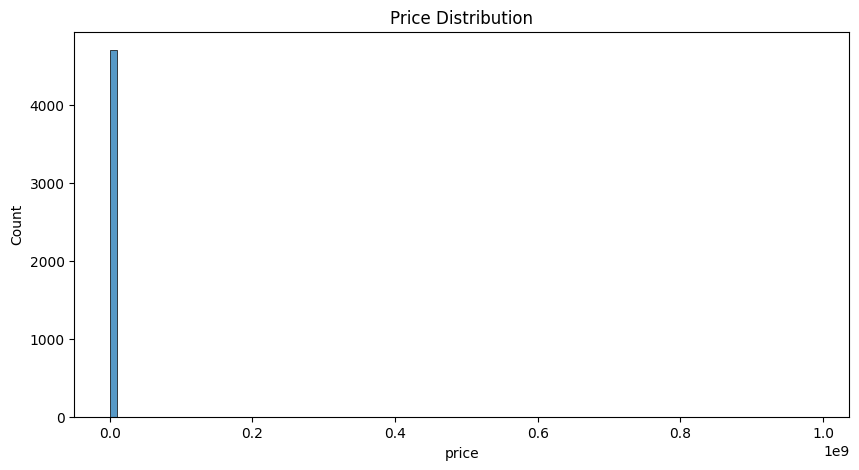

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=100)
plt.title("Price Distribution")
plt.show()

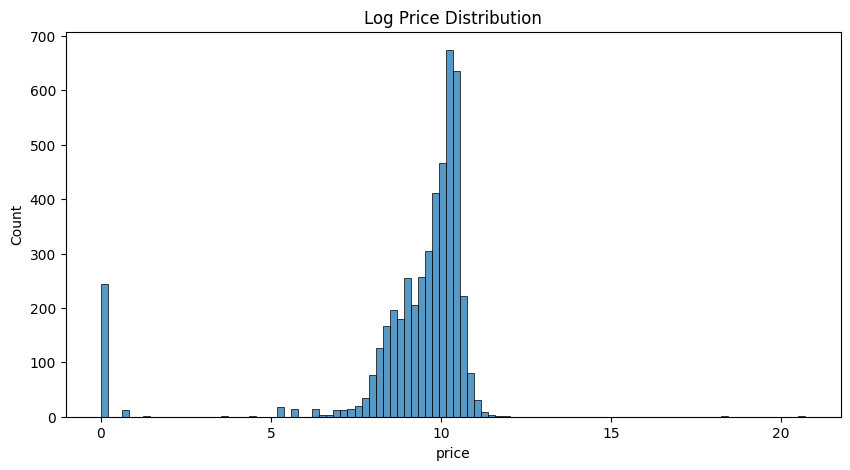

In [106]:
import numpy as np

plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df['price']), bins=100)
plt.title("Log Price Distribution")
plt.show()

BURAYA KADARKİ DATASET KAYDEDİLDİ.

In [107]:
df_clean = df.copy()
df.to_csv("cleaned_data.csv", index=False)

In [108]:
df['price'].describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99])

,price
count,4.706000e+03
mean,2.506757e+05
std,1.447023e+07
min,0.000000e+00
50%,1.850000e+04
75%,2.959000e+04
90%,3.659000e+04
95%,4.059000e+04
99%,5.798300e+04
max,9.876543e+08


In [109]:
df['km'].describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99])

,km
count,4.706000e+03
mean,1.368324e+05
std,6.451517e+05
min,0.000000e+00
50%,7.910100e+04
75%,1.428905e+05
90%,1.912145e+05
95%,2.195810e+05
99%,3.397500e+05
max,9.999999e+06


In [110]:
df['car_age'].describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99])

,car_age
count,4706.000000
mean,12.223544
std,9.462323
min,3.000000
50%,10.000000
75%,15.000000
90%,20.000000
95%,25.000000
99%,56.000000
max,121.000000


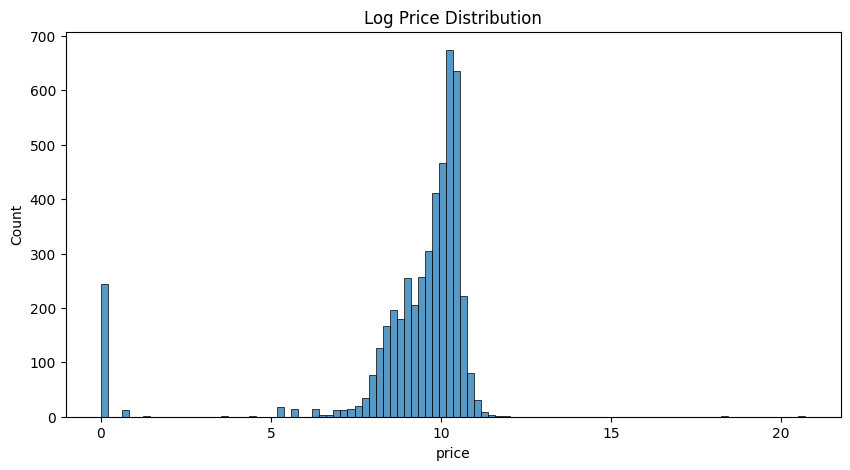

In [111]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df['price']), bins=100)
plt.title("Log Price Distribution")
plt.show()

PRICE İÇİN OUTLİER ANALİZİ

In [112]:
price_95 = df['price'].quantile(0.95)
price_99 = df['price'].quantile(0.99)

In [113]:
# Price = 0 veya 99. percentile üstü
price_outlier_mask = (df['price'] == 0) | (df['price'] > price_99)

In [114]:
df[price_outlier_mask].shape[0]

292

KM İÇİN OUTLİER ANALİZİ:

In [115]:
km_99 = df['km'].quantile(0.99)  # 279,000 civarı

In [116]:
km_outlier_mask = (df['km'] == 0) | (df['km'] > km_99)

In [117]:
df[km_outlier_mask].shape[0]

66

CAR AGE İÇİN OUTLİER ANALİZİ:

In [118]:
car_age_99 = df['car_age'].quantile(0.99)  # 58 civarı

In [119]:
car_age_outlier_mask = df['car_age'] > car_age_99

In [120]:
df[car_age_outlier_mask].shape[0]

47

In [121]:
all_outliers_mask = price_outlier_mask | km_outlier_mask | car_age_outlier_mask
df_outliers = df[all_outliers_mask]
df_outliers.shape  # kaç satır uç değer
df_outliers.head()  # ilk 5 outlier aracı gör

,city,price,brand,model,condition,engine_cylinders,fuel,km,title_condition,gearbox,drive_type,car_type,state,car_age
10,el paso,0,unknown,unknown,unknown,6.0,unknown,79101.0,unknown,unknown,unknown,unknown,tx,10.0
11,el paso,0,unknown,unknown,unknown,6.0,unknown,79101.0,unknown,unknown,unknown,unknown,tx,10.0
12,el paso,0,unknown,unknown,unknown,6.0,unknown,79101.0,unknown,unknown,unknown,unknown,tx,10.0
13,el paso,0,unknown,unknown,unknown,6.0,unknown,79101.0,unknown,unknown,unknown,unknown,tx,10.0
14,el paso,0,unknown,unknown,unknown,6.0,unknown,79101.0,unknown,unknown,unknown,unknown,tx,10.0


In [122]:
df_cleaned = df[~all_outliers_mask]  # outlier’lar temizlendi
df_cleaned.shape  # kaç satır kaldı

(4351, 14)

In [123]:
df_cleaned['engine_cylinders'] = df_cleaned['engine_cylinders'].astype(str).str.replace(' cylinders', '')
df_cleaned['engine_cylinders'] = pd.to_numeric(df_cleaned['engine_cylinders'], errors='coerce')
df_cleaned['engine_cylinders'].fillna(df_cleaned['engine_cylinders'].median(), inplace=True)

/tmp/ipykernel_13647/1147099036.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['engine_cylinders'] = df_cleaned['engine_cylinders'].astype(str).str.replace(' cylinders', '')
/tmp/ipykernel_13647/1147099036.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['engine_cylinders'] = pd.to_numeric(df_cleaned['engine_cylinders'], errors='coerce')
/tmp/ipykernel_13647/1147099036.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment

In [124]:
from sklearn.preprocessing import LabelEncoder

# --- Label Encoding kolonları ---
label_cols = ['state', 'brand', 'model']
le = LabelEncoder()
for col in label_cols:
    df_cleaned[col + '_encoded'] = le.fit_transform(df_cleaned[col])

# --- One-Hot Encoding kolonları ---
onehot_cols = ['fuel', 'gearbox', 'drive_type', 'condition', 'title_condition', 'car_type']
df_cleaned = pd.get_dummies(df_cleaned, columns=onehot_cols, prefix=onehot_cols)

/tmp/ipykernel_13647/443532388.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[col + '_encoded'] = le.fit_transform(df_cleaned[col])
/tmp/ipykernel_13647/443532388.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[col + '_encoded'] = le.fit_transform(df_cleaned[col])
/tmp/ipykernel_13647/443532388.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

In [125]:
# Kategorik kolonlardan bazı örnekleri görelim
df_cleaned.head(3)
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4351 entries, 0 to 4705
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        4351 non-null   object 
 1   price                       4351 non-null   int64  
 2   brand                       4351 non-null   object 
 3   model                       4351 non-null   object 
 4   engine_cylinders            4351 non-null   float64
 5   km                          4351 non-null   float64
 6   state                       4351 non-null   object 
 7   car_age                     4351 non-null   float64
 8   state_encoded               4351 non-null   int64  
 9   brand_encoded               4351 non-null   int64  
 10  model_encoded               4351 non-null   int64  
 11  fuel_diesel                 4351 non-null   bool   
 12  fuel_electric               4351 non-null   bool   
 13  fuel_gas                    4351 non-n

BU NE YAPIYOR?

👉 object olanları atıyor:

city
brand
model
state

👉 Geri kalan:

encoded kolonlar
numeric kolonlar
bool kolonlar
🔥 EN TEMİZ YÖNTEM BU

Senin 53 kolonun:

✔️ 42 bool
✔️ numericler
✔️ encodedlar

👉 HEPSİ MODELE GİDİYOR

In [126]:
# TARGET
y = df_cleaned['price']

# SADECE MODELİN ANLAYACAĞI KOLONLAR
X = df_cleaned.select_dtypes(exclude=['object'])

# price'ı çıkar (target olduğu için)
X = X.drop(columns=['price'])

In [127]:
import pandas as pd

df = pd.read_csv("/content/cleaned_data.csv", engine="python", on_bad_lines='skip')

df.shape

(4706, 14)

In [128]:
df.head()
df.isnull().sum()

,0
city,0
price,0
brand,0
model,0
condition,0
engine_cylinders,0
fuel,0
km,0
title_condition,0
gearbox,0


In [129]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4351 entries, 0 to 4705
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   engine_cylinders            4351 non-null   float64
 1   km                          4351 non-null   float64
 2   car_age                     4351 non-null   float64
 3   state_encoded               4351 non-null   int64  
 4   brand_encoded               4351 non-null   int64  
 5   model_encoded               4351 non-null   int64  
 6   fuel_diesel                 4351 non-null   bool   
 7   fuel_electric               4351 non-null   bool   
 8   fuel_gas                    4351 non-null   bool   
 9   fuel_hybrid                 4351 non-null   bool   
 10  fuel_other                  4351 non-null   bool   
 11  fuel_unknown                4351 non-null   bool   
 12  gearbox_automatic           4351 non-null   bool   
 13  gearbox_manual              4351 non-n

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [131]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [132]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [133]:
y_pred = model.predict(X_test)

In [134]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2642.982326538782
RMSE: 4620.123740271218
R2: 0.86061769037795


In [135]:
import pandas as pd

importances = model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(10)

,feature,importance
2,car_age,0.340634
1,km,0.275652
17,drive_type_fwd,0.073288
5,model_encoded,0.063524
4,brand_encoded,0.037052
0,engine_cylinders,0.034301
6,fuel_diesel,0.027905
21,condition_fair,0.021685
16,drive_type_4wd,0.018954
45,car_type_unknown,0.010147


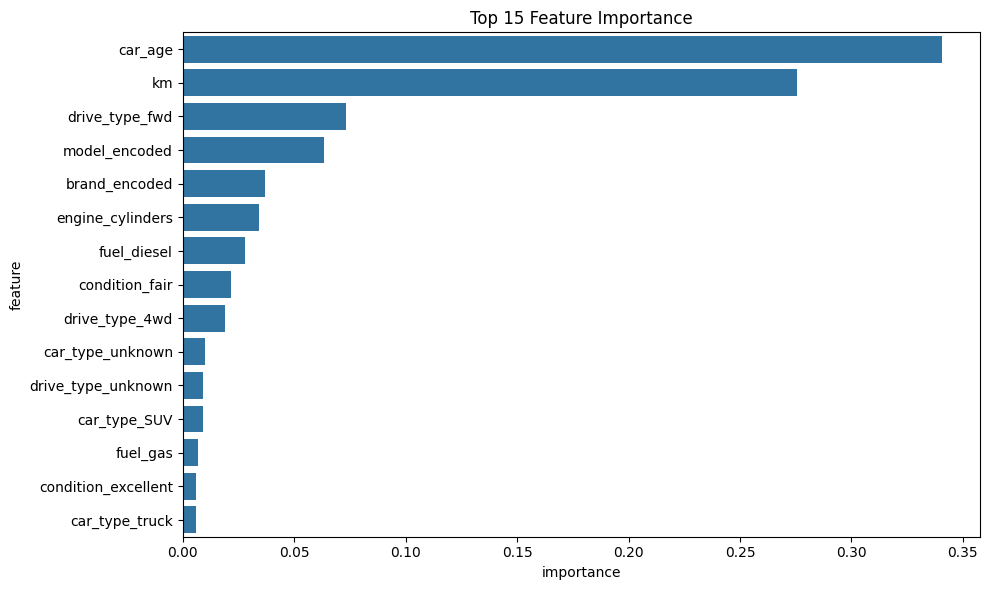

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature importance dataframe hazır olsun
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_  # model RandomForest kullanıyorsa
})

# Önem sırasına göre sırala
feature_importance = feature_importance.sort_values(by='importance', ascending=False)

# Bar plot
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15))  # ilk 15 önemli feature
plt.title("Top 15 Feature Importance")
plt.tight_layout()
plt.show()

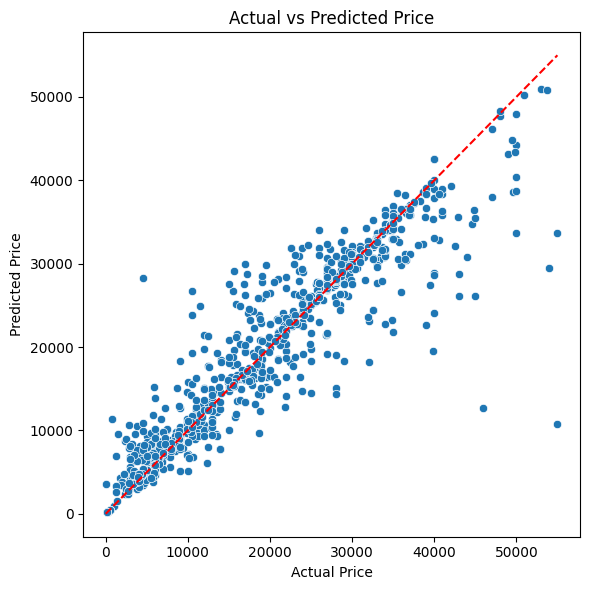

In [137]:
# Tahminleri al
y_pred = model.predict(X_test)

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45 derece çizgi
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.tight_layout()
plt.show()

In [140]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# y_test ve y_pred_xgb hazır varsayalım
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))  # squared=False yerine böyle
r2 = r2_score(y_test, y_pred_xgb)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2889.201171875
RMSE: 4546.326869022948
R2: 0.865034818649292


In [141]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)

# Ölçümler
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))  # eski sürüm uyumlu
r2_best = r2_score(y_test, y_pred_best)

print("Tuned XGB MAE:", mae_best)
print("Tuned XGB RMSE:", rmse_best)
print("Tuned XGB R2:", r2_best)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, n_estimators=300, subsample=0.7; total time=   1.1s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, n_estimators=300, subsample=0.7; total time=   1.2s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, n_estimators=300, subsample=0.7; total time=   1.2s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.7; total time=   1.8s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.7; total time=   2.6s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.7; total time=   4.7s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=5, n_estimators=300, subsample=1; total time=   0.9s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=5, n_estimators=300, subsample=1; total time=   2.4s
[CV] END colsampl